In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [22]:
df = pd.read_csv("../hamiltonians/N2/results_N2.csv", decimal=",")

In [23]:
df

,bond,symmetries,orbital,E_dec,K,maxdim,nc_score,highest_sec_state,note,e_fci
0,1.1,sen,mo,-107.586406,23,120,2.472508,19,20_sps,-107.654122
1,1.1,sen,opt,-107.588538,22,120,2.412626,19,20_sps,-107.654122
2,1.1,senquart,mo,-107.633409,8,416,0.508879,80,100_sps,-107.654122
3,1.1,senquart,opt,-107.649125,5,416,0.125915,63,100_sps,-107.654122
4,1.1,corepop,mo,-107.623102,22,400,0.436087,152,500_sps,-107.654122
5,1.1,corepop,opt,-107.638140,13,400,0.225153,76,500_sps,-107.654122
6,1.5,sen,mo,-107.500357,31,120,2.229027,21,100_sps,-107.581635
7,1.5,sen,opt,-107.507067,27,120,2.158171,24,100_sps,-107.581635
8,1.5,senquart,mo,-107.559370,15,416,0.348089,138,500_sps,-107.581635
9,1.5,senquart,opt,-107.576609,5,416,0.097758,133,500_sps,-107.581635


In [24]:
sen_mo = df.loc[(df["symmetries"]=="sen") & (df["orbital"]=="mo")]
sen_opt = df.loc[(df["symmetries"]=="sen") & (df["orbital"]=="opt")]

senquart_mo = df.loc[(df["symmetries"]=="senquart") & (df["orbital"]=="mo")]
senquart_opt = df.loc[(df["symmetries"]=="senquart") & (df["orbital"]=="opt")]

corepop_mo = df.loc[(df["symmetries"]=="corepop") & (df["orbital"]=="mo")]
corepop_opt = df.loc[(df["symmetries"]=="corepop") & (df["orbital"]=="opt")]

In [30]:
plt.rcParams.update({"font.size":13})

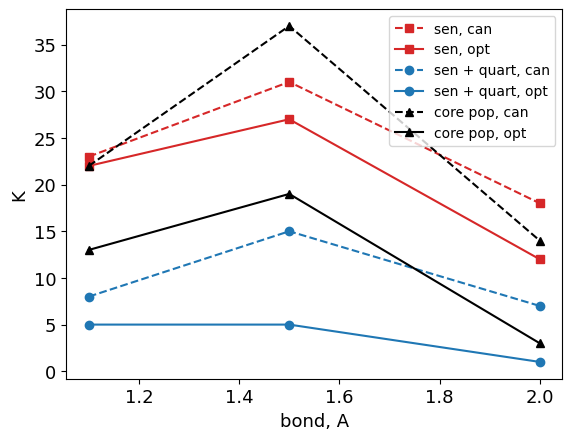

In [36]:
data = (sen_mo, sen_opt, senquart_mo, senquart_opt, corepop_mo, corepop_opt)
colors = ("tab:red", "tab:red", "tab:blue", "tab:blue", "black", "black")
linestyles = ["--", "-"] * 3

titles = ["sen, can", "sen, opt", "sen + quart, can",
         "sen + quart, opt", "core pop, can", "core pop, opt"]

markers = ["s", "s", "o", "o", "^", "^"]

for i in range(6):
    plt.plot(data[i]["bond"], data[i]["K"], label=titles[i], color=colors[i],
             linestyle=linestyles[i], marker=markers[i])
    
plt.ylabel("K")
plt.xlabel("bond, A")
plt.legend(fontsize=10)
plt.savefig("N2_K.png", format="png", dpi=400, bbox_inches="tight")
plt.show()

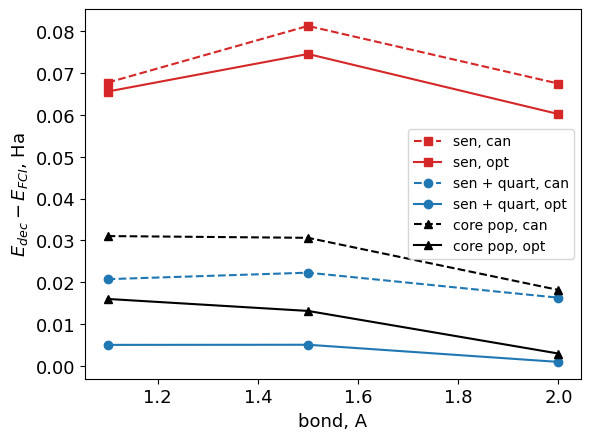

In [37]:
for i in range(6):
    plt.plot(data[i]["bond"], data[i]["E_dec"] - data[i]["e_fci"], 
             label=titles[i], color=colors[i],
             linestyle=linestyles[i], marker=markers[i])
    
plt.ylabel("$E_{dec} - E_{FCI}$, Ha")
plt.xlabel("bond, A")
plt.legend(fontsize=10)
plt.savefig("N2_dE.png", format="png", dpi=400, bbox_inches="tight")
plt.show()

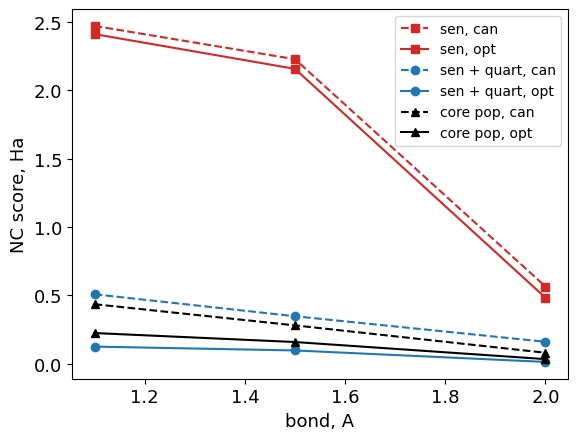

In [38]:
for i in range(6):
    plt.plot(data[i]["bond"], data[i]["nc_score"], 
             label=titles[i], color=colors[i],
             linestyle=linestyles[i], marker=markers[i])
    
plt.ylabel("NC score, Ha")
plt.xlabel("bond, A")
plt.legend(fontsize=10)
plt.savefig("N2_NC.png", format="png", dpi=400, bbox_inches="tight")

plt.show()